In [2]:
from google.colab import drive

drive.mount('/content/drive')

# # 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [76]:
import pandas as pd

path = "/content/drive/MyDrive/Data/inbound-tourism-analysis/data/"

# CSVの読み込み
vis = pd.read_csv(path + "foreign_visitors_yearly.csv")
exp = pd.read_csv(path + "expenditure_per_foreign_tourist.csv")
fx = pd.read_csv(path + "exchange_rate_monthly.csv", encoding="shift-jis",
                 skiprows=2, names=["date", "usd_jpy", "reer"])

# カンマ除去 → int型に変換
vis["Visitor Arrivals"] = vis["Visitor Arrivals"].str.replace(",", "").astype(int)
exp["Consumption Amount"] = exp["Consumption Amount"].str.replace(",", "").astype(int)

# float型に変換
vis["Growth Rate(%)"] = vis["Growth Rate(%)"].str.replace(",", "").astype(float)

# 列の調整
exp.columns = exp.columns.str.strip()

# Year → yearに統一
vis = vis.rename(columns={"Year": "year"})
exp = exp.rename(columns={"Year": "year"})

In [79]:
# 月為替データから年間為替データを作成

# 年を取り出す
fx["year"] = fx["date"].str[:4].astype(int)

# 為替レートの年平均を計算
yearly = fx.groupby("year")[["usd_jpy", "reer"]].mean().reset_index()

# 保存
# yearly.to_csv(path + "exchange_rate_yearly.csv", index=False)

fx = yearly.copy()

fx.head()

,year,usd_jpy,reer
0,1980,226.685000,106.320833
1,1981,220.549167,111.106667
2,1982,249.064167,100.278333
3,1983,237.481667,107.285833
4,1984,237.528333,109.940000


In [83]:
# 結合（訪日外国人1人あたりの旅行支出額、年間訪日外客数、年間為替レート）
df = exp.merge(vis, on="year").merge(fx, on="year")

# df.to_csv(path + "tourism_merged.csv", index=False)

df

,year,Consumption Amount,Visitor Arrivals,Growth Rate(%),usd_jpy,reer
0,2011,130819,6218752,-27.782771,79.780833,130.317500
1,2012,129798,8358105,34.401645,79.789167,128.685000
2,2013,136693,10363904,23.998251,97.600000,102.526667
3,2014,151174,13413467,29.424848,105.835833,96.625833
4,2015,176167,19737409,47.146215,121.021667,90.142500
5,2016,155896,24039700,21.797648,108.835833,102.163333
6,2017,153921,28691073,19.348715,112.159167,97.194167
7,2018,153029,31191856,8.716241,110.402500,96.211667
8,2019,158531,31882049,2.212735,109.013333,99.055833
9,2024,226851,36870148,47.090215,151.498333,70.845000


In [81]:
import pandas as pd

# 結合CSVの読み込み
# df = pd.read_csv(path + "tourism_merged.csv")

# Term列の削除
df = df.drop("Term", axis=1)

# 外れ値（2023年）の削除
df = df[df["year"] != 2023].reset_index(drop=True)

df.dtypes

,0
year,int64
Consumption Amount,int64
Visitor Arrivals,int64
Growth Rate(%),float64
usd_jpy,float64
reer,float64


In [82]:
# 相関
df.corr(numeric_only=True)

,year,Consumption Amount,Visitor Arrivals,Growth Rate(%),usd_jpy,reer
year,1.000000,0.867881,0.946044,0.341137,0.896201,-0.836225
Consumption Amount,0.867881,1.000000,0.724304,0.555154,0.960283,-0.866038
Visitor Arrivals,0.946044,0.724304,1.000000,0.223969,0.808238,-0.770329
Growth Rate(%),0.341137,0.555154,0.223969,1.000000,0.572861,-0.588115
usd_jpy,0.896201,0.960283,0.808238,0.572861,1.000000,-0.964607
reer,-0.836225,-0.866038,-0.770329,-0.588115,-0.964607,1.000000


##　相関分析の結果
- 訪日客数の前年比増加率 (Growth Rate(%)) と 円安 (usd_jpy) の相関係数は 0.572861 であり、円安になると訪日客の増加率が上昇する傾向が確認された（中程度の相関）。

- year と 円安 (usd_jpy) の相関は 0.896201 と非常に高く、時間の経過とともに円安が進行していることが確認された。ただし、 year は分析対象から除外する。

- 訪日客数(Visitor Arrivals) と 円安(usd_jpy) には 比較的強い相関（0.808238） が確認された。

- 観光消費額 (Consumption Amount) と円安(usd_jpy) の相関（0.960283）は、時間トレンドの影響を受けた トレンド相関 の可能性が高い。

- 訪日客数 (Visitor Arrivals) と観光消費額 (Consumption Amount) には 中程度の相関（0.724304） が確認され、訪日客数の増加が消費拡大に寄与している可能性がある。
----------------
## 考察

本分析から、円安はインバウンド増加の要因の一つである可能性が示唆された。ただし、インバウンド需要は為替以外にも、以下の要因の影響を受けるため、為替のみで説明することはできない。

#####・ビザ緩和
#####・LCC増加
#####・中国観光客
#####・コロナ
----------------
## 結論
円安は訪日客増加と一定の関連を持つが、インバウンド増加の唯一の要因ではない。


### ＜補足＞実質実効為替レート（物価調整＋多通貨）

- usd_jpy：ドル円（名目為替）
- reer   ：実質実効為替レート（物価調整＋多通貨）
---
1. usd_jpy と reer の関係はほぼ完全な逆相関（-0.964）
2. 円安になるほど、日本の「実質的な購買力」は低下する
#### REERが下がると
- 円の実質価値が下がる
- 日本の財・サービスが相対的に安くなる
- 外国人から見て「日本が安くなる」

# 年次推移（訪日客数 / 為替 / 消費）

In [29]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 38.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=c4807e247d5b064b8eaf6a9304f4365c4df8c81e82afa29a80ae10cae2eb59fc
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


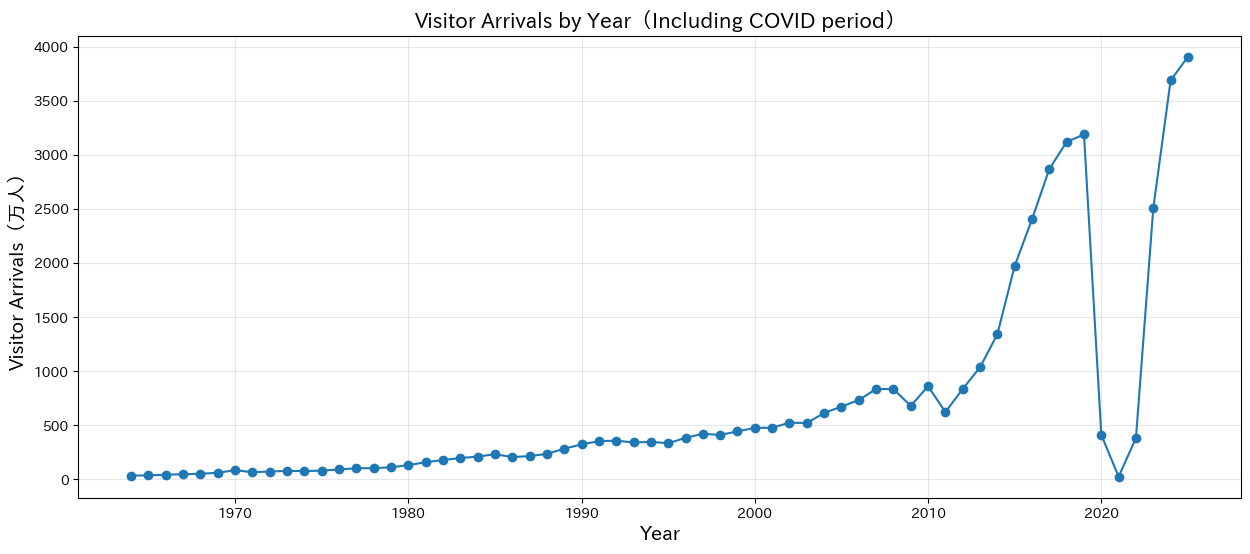

In [70]:
import japanize_matplotlib
import matplotlib.pyplot as plt

# 訪日客数（年次）

# 訪日客数を「万人」に変換
plt.figure(figsize=(15,6))
plt.plot(vis["year"], vis["Visitor Arrivals"] / 10000, marker="o")

plt.xlabel("Year", fontsize=14)
plt.ylabel("Visitor Arrivals（万人）", fontsize=14)
plt.title("Visitor Arrivals by Year（Including COVID period）", fontsize=15)
plt.grid(True, alpha=0.3)

plt.show()

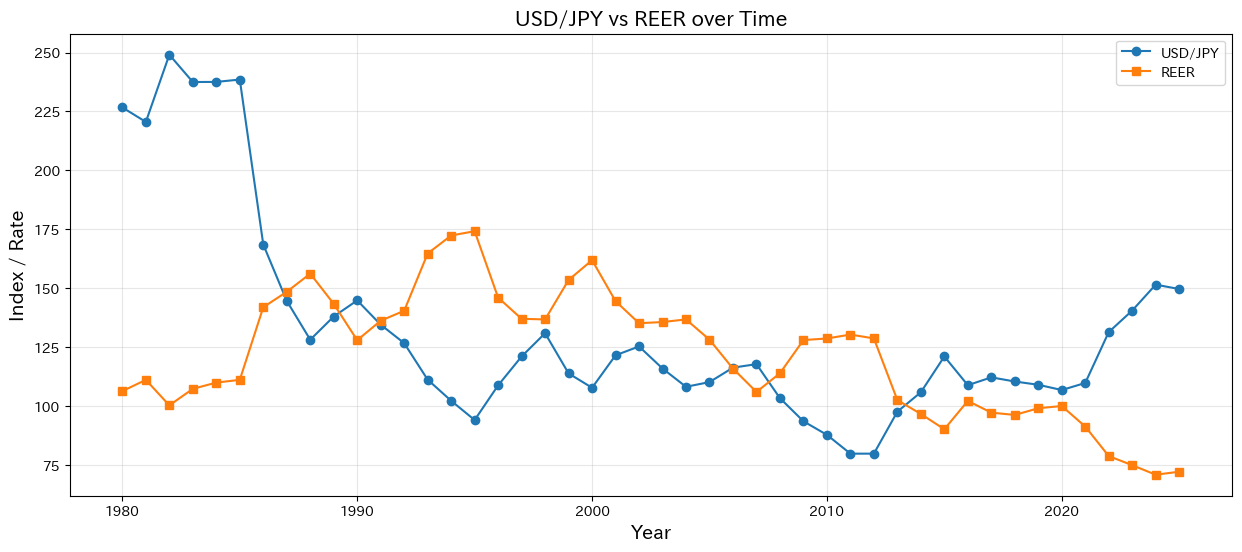

In [88]:
# ② 為替（年次）
plt.figure(figsize=(15,6))

# usd_jpy（左軸）
plt.plot(fx["year"], fx["usd_jpy"], marker="o", label="USD/JPY")

# reer（同じ軸で一旦表示）
plt.plot(fx["year"], fx["reer"], marker="s", label="REER")

plt.xlabel("Year", fontsize=14)
plt.ylabel("Index / Rate", fontsize=14)
plt.title("USD/JPY vs REER over Time", fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

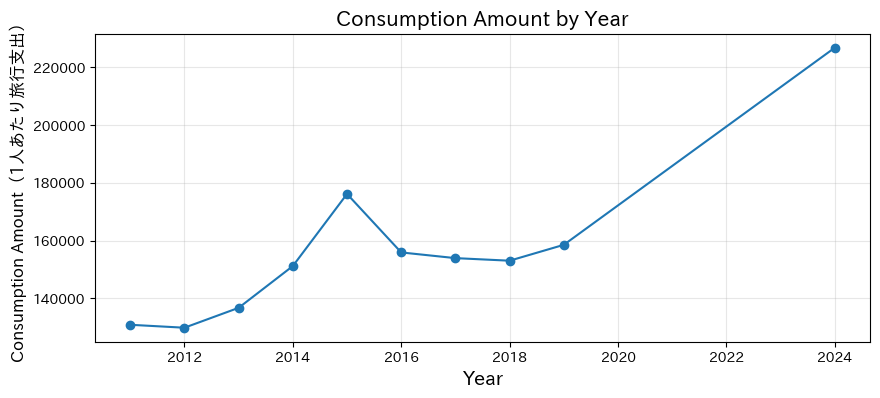

In [92]:
# ③ 消費額（年次）
plt.figure(figsize=(10,4))
plt.plot(df["year"], df["Consumption Amount"], marker="o")

plt.xlabel("Year", fontsize=14)
plt.ylabel("Consumption Amount（1人あたり旅行支出）", fontsize=12)
plt.title("Consumption Amount by Year", fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()

# 回帰線付き散布図（為替 × 訪日客数）
為替レートと訪日客数の関係を直線で近似して視覚化

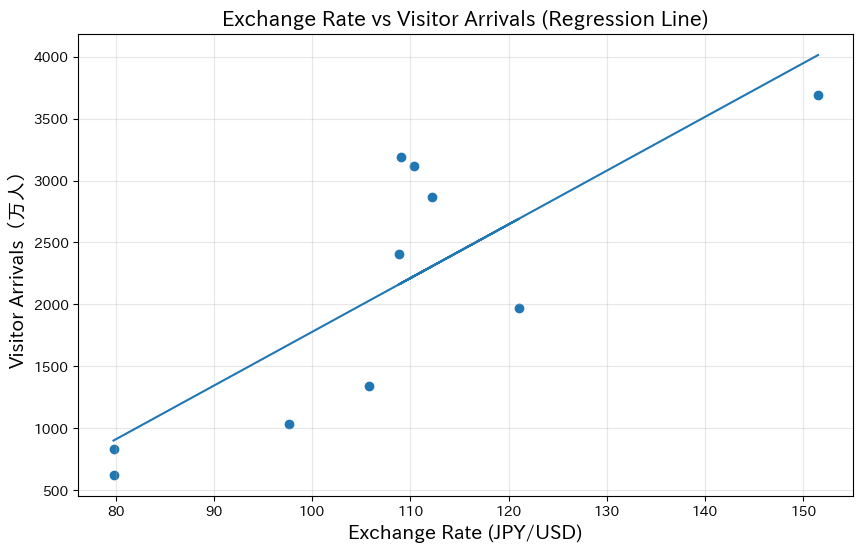

In [96]:
import numpy as np
import matplotlib.pyplot as plt

x = df["usd_jpy"]
y = df["Visitor Arrivals"] / 10000

plt.figure(figsize=(10, 6))
plt.scatter(x, y)

plt.xlabel("Exchange Rate (JPY/USD)", fontsize=14)
plt.ylabel("Visitor Arrivals（万人）", fontsize=14)
plt.title("Exchange Rate vs Visitor Arrivals (Regression Line)", fontsize=15)

plt.grid(True, alpha=0.3)

# -----回帰線-----
# 年平均のドル円為替レートを説明変数、訪日客数を目的変数として単回帰分析を行った。
# NumPy の polyfit() 関数を用いて最小二乗法により回帰式
# VisitorArrivals=m×USDJPY+b
# を推定し、その回帰直線を Matplotlib により可視化した。
# -----English-----
# A simple linear regression was estimated using the annual average USD/JPY exchange rate as the explanatory
# variable and the number of visitor arrivals as the dependent variable.
# The regression coefficients were calculated using NumPy’s polyfit() function based on the least squares method,
# and the regression line was visualized using Matplotlib.
# ---補足---
# m（傾き）→ 為替レートが1円変化したとき、訪日客数がどれだけ変化するか
# b（切片）→ 為替が0円だったと仮定した場合の訪日客数（※実際の意味はほぼない）
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# 写真
# plt.savefig(path + "exchange_vs_visitors.png")

plt.show()

#　回帰分析

### 「為替 → 観光客数」

In [97]:
import statsmodels.api as sm

# 説明変数
X = df["usd_jpy"]

# 定数項追加
X = sm.add_constant(X)

# 目的変数
y = df["Visitor Arrivals"]

# 回帰
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Visitor Arrivals   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     15.07
Date:                Fri, 17 Apr 2026   Prob (F-statistic):            0.00466
Time:                        17:12:55   Log-Likelihood:                -170.52
No. Observations:                  10   AIC:                             345.0
Df Residuals:                       8   BIC:                             345.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.563e+07   1.22e+07     -2.096      0.0

- usd_jpy   coef = 4.341e+05　から、為替が1円円安になると
約43万人訪日客が増えることがわかる。
- P>|t| = 0.005（統計的に非常に有意）
- R-squared = 0.653は、訪日客数の変動の65%を為替が説明している。
- Prob (F-statistic) = 0.00466から、このモデルは統計的に有意。為替 → 訪日客という関係は偶然ではない可能性が高い。

###「観光客数 → 消費額」

In [98]:
import statsmodels.api as sm

# 説明変数
X = df["Visitor Arrivals"]

# 定数追加
X = sm.add_constant(X)

# 目的変数
y = df["Consumption Amount"]

# 回帰
model = sm.OLS(y, X).fit()

# 結果
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Consumption Amount   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     8.828
Date:                Fri, 17 Apr 2026   Prob (F-statistic):             0.0178
Time:                        17:14:33   Log-Likelihood:                -112.41
No. Observations:                  10   AIC:                             228.8
Df Residuals:                       8   BIC:                             229.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.183e+05   1.47e+04  

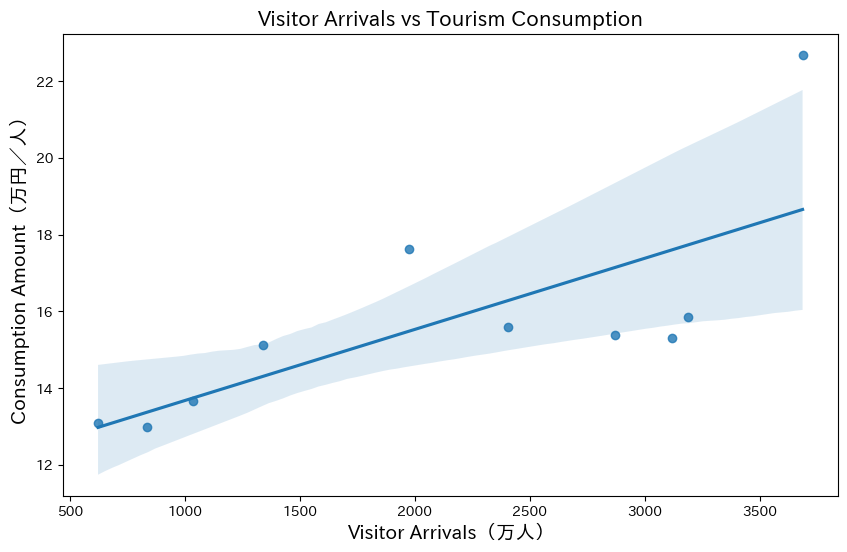

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.regplot(
    x=df["Visitor Arrivals"] / 10000,
    y=df["Consumption Amount"] / 10000
)

plt.title("Visitor Arrivals vs Tourism Consumption", fontsize=15)
plt.xlabel("Visitor Arrivals（万人）", fontsize=14)
plt.ylabel("Consumption Amount（万円／人）", fontsize=14)

# 保存
# plt.savefig(path + "visitors_vs_consumption.png")

plt.show()